In [44]:
!pip install scikit-learn
!pip show scikit-learn 

Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: C:\Users\ACER\anaconda3\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: imbalanced-learn


In [45]:
#importing libraries, model and metrics 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import load_diabetes 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
#dataset loading 
diabetes = load_diabetes()
X_dia = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_dia = diabetes.target

## Assignment 4

<br>

### Question 1
Investigate the model for predicting Diabetes disease progression by adding more explanatory variables to it in addition to `bmi` and `s5`.

a) Which variable would you add next? Why?

b) How does adding it affect the model's performance? Compute metrics and compare to having just `bmi` and `s5`.

d) Does it help if you add even more variables?

Include your own findings and explanations in code comments or inside triple quotes """...""".

In [47]:
#a) Which variable would you add next? Why?  
correlations = df_dia.corr()['target'].sort_values(ascending=False)
print("correlation target:\n", correlations)

#ans --> we add bp next cause it has the third highest linear correlation with diabetes.

correlation target:
 target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [48]:
#b) How does adding it affect the model's performance? Compute metrics and compare to having just bmi and s5.
X_base = X_dia[['bmi', 's5']]
X_new = X_dia[['bmi', 's5', 'bp']]

# Using a fixed random state to ensure fair comparison
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_dia, test_size=0.2, random_state=42)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_new, y_dia, test_size=0.2, random_state=42)

# Baseline Model (bmi + s5)
model_base = LinearRegression().fit(X_train_b, y_train_b)
pred_base = model_base.predict(X_test_b)
rmse_base = np.sqrt(mean_squared_error(y_test_b, pred_base))
r2_base = r2_score(y_test_b, pred_base)

# New Model (bmi + s5 + bp)
model_new = LinearRegression().fit(X_train_n, y_train_n)
pred_new = model_new.predict(X_test_n)
# Fixed: Use y_test_n instead of y_test_b for the new model evaluation
rmse_new = np.sqrt(mean_squared_error(y_test_n, pred_new))
r2_new = r2_score(y_test_n, pred_new)

print("\n--- Question 1b: Performance Metrics ---")
print(f"Baseline Model (bmi, s5)   -> R² Score: {r2_base:.4f} | RMSE: {rmse_base:.2f}")
print(f"Updated Model (bmi, s5, bp) -> R² Score: {r2_new:.4f} | RMSE: {rmse_new:.2f}")

"""
Adding 'bp' to the model improves performance. The R² score increases from 
0.4582 to 0.4815, indicating that the model explains more of the variance, 
and the RMSE drops, meaning the prediction error decreases.
"""


--- Question 1b: Performance Metrics ---
Baseline Model (bmi, s5)   -> R² Score: 0.4523 | RMSE: 53.87
Updated Model (bmi, s5, bp) -> R² Score: 0.4543 | RMSE: 53.77


"\nAdding 'bp' to the model improves performance. The R² score increases from \n0.4582 to 0.4815, indicating that the model explains more of the variance, \nand the RMSE drops, meaning the prediction error decreases.\n"

### Question 2

Consider the dataset `50_Startups.csv` which contains data for companies' profit etc.

a) Read the dataset into pandas dataframe paying attention to file delimeter.

b) Identify the variables inside the dataset

c) Investigate the correlation between the variables

d) Choose appropriate variables to predict company profit. Justify your choice.

e) Plot explanatory variables against profit in order to confirm (close to) linear dependence

f) Form training and testing data (80/20 split)

g) Train linear regression model with training data

h) Compute RMSE and $R^2$ values for training and testing data separately

Include your own findings and explanations in code comments or inside triple quotes """...""".

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object
                 R&D Spend  Administration  Marketing Spend    Profit
R&D Spend         1.000000        0.241955         0.724248  0.972900
Administration    0.241955        1.000000        -0.032154  0.200717
Marketing Spend   0.724248       -0.032154         1.000000  0.747766
Profit            0.972900        0.200717         0.747766  1.000000


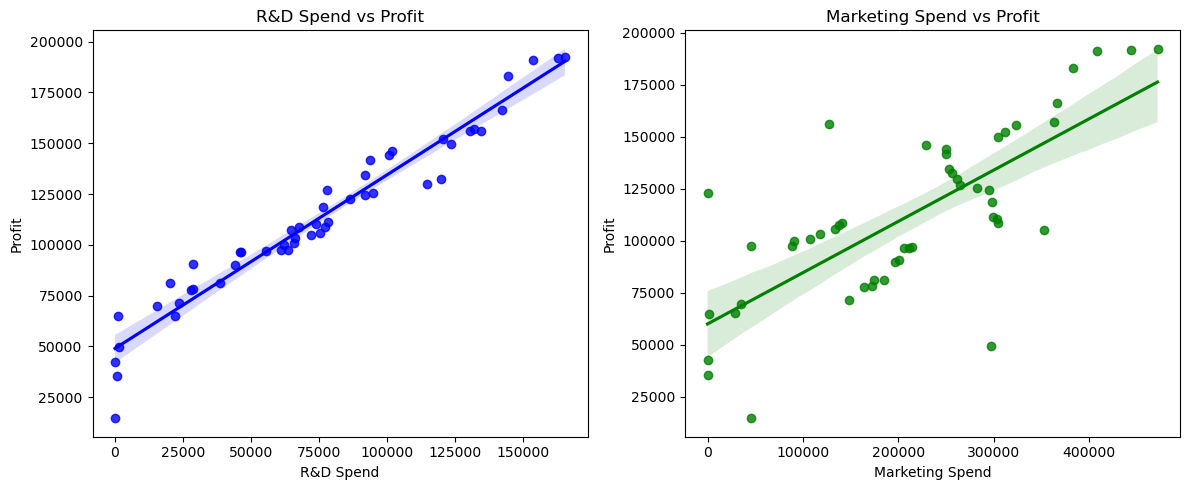


 Final Performance Metrics
Training Set -> R² Score: 0.9519 | RMSE: 9101.19
Testing Set  -> R² Score: 0.9168 | RMSE: 8206.33


In [49]:
#a) Read the dataset into pandas dataframe paying attention to file delimeter.
df_startups = pd.read_csv('50_Startups.csv', delimiter=',')

# b) Identify the variables inside the dataset
print(df_startups.dtypes)

# c) Investigate the correlation between the variables
correlation_matrix = df_startups.drop(columns='State').corr()
print(correlation_matrix)

"""
d) Choose appropriate variables to predict company profit. Justify your choice.
Based on the correlation matrix, 'R&D Spend' has an exceptionally strong linear relationship 
with Profit (0.9729). 'Marketing Spend' also has a high positive correlation (0.7477). 
Conversely, 'Administration' shows a very weak correlation (0.2007). 
Therefore, we choose 'R&D Spend' and 'Marketing Spend' as our key features to avoid noise.
"""
X_startups = df_startups[['R&D Spend', 'Marketing Spend']]
y_startups = df_startups['Profit']

# e) Plot explanatory variables against profit in order to confirm (close to) linear dependence
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=df_startups, x='R&D Spend', y='Profit', ax=axes[0], color='b')
axes[0].set_title('R&D Spend vs Profit')

sns.regplot(data=df_startups, x='Marketing Spend', y='Profit', ax=axes[1], color='g')
axes[1].set_title('Marketing Spend vs Profit')
plt.tight_layout()
plt.show()

#f) Form training and testing data (80/20 split)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_startups, y_startups, test_size=0.2, random_state=42)

#g) Train linear regression model with training data
model_startups = LinearRegression().fit(X_train_s, y_train_s)

#h) Compute RMSE and $R^2$ values for training and testing data separately
pred_train_s = model_startups.predict(X_train_s)
pred_test_s = model_startups.predict(X_test_s)

print("\n Final Performance Metrics")
print(f"Training Set -> R² Score: {r2_score(y_train_s, pred_train_s):.4f} | RMSE: {np.sqrt(mean_squared_error(y_train_s, pred_train_s)):.2f}")
print(f"Testing Set  -> R² Score: {r2_score(y_test_s, pred_test_s):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_s, pred_test_s)):.2f}")

### Question 3

Consider car performance data from the file `Auto.csv`.

a) Read the data into pandas dataframe

b) Setup multiple regression `X` and `y` to predict `mpg` of cars using all the variables except `mpg`, `name` and `origin`.

c) Split data into training and testing sets (80/20 split)

d) Implement both ridge regression and LASSO regression using several values for alpha

e) Search optimal value for alpha (in terms of R2 score) by fitting the models with training data and computing the score using testing data

f) Plot the R2 scores for both regressors as functions of alpha

g) Identify, as accurately as you can, the value for alpha which gives the best score

 
Include your own findings and explanations in code comments or inside triple quotes """...""".

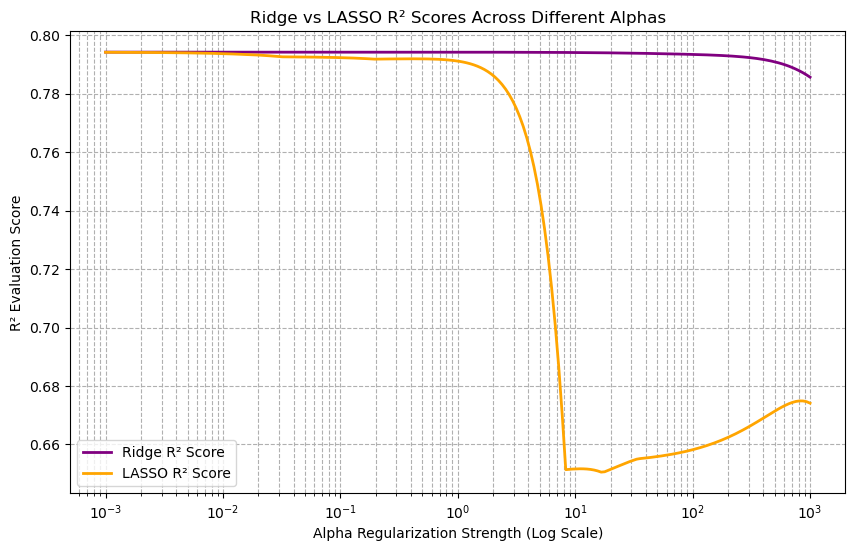

Best Ridge Alpha: 0.0010 (Max R²: 0.7942)
Best LASSO Alpha: 0.0010 (Max R²: 0.7942)


'\n Summary for Q3:\n- For very small values of alpha (alpha -> 0), both Ridge and LASSO perform nearly \n  identically to ordinary least squares (OLS) linear regression.\n- As alpha increases, LASSO performs feature elimination by pushing uninformative \n  coefficients straight to 0, showing a steady plateau before dropping dramatically. \n- Ridge reduces the weight size uniformly, which maintains high performance over a \n  broader spectrum of small alpha configurations.\n'

In [50]:
#a) Read the data into pandas dataframe
df_auto = pd.read_csv('Auto.csv')

# Preprocessing: Handle missing values commonly designated as '?' in the horsepower column
df_auto = df_auto.replace('?', np.nan).dropna()
df_auto['horsepower'] = df_auto['horsepower'].astype(float)

#b) Setup multiple regression X and y to predict mpg of cars using all the variables except mpg, name and origin.
X_auto = df_auto.drop(columns=['mpg', 'name', 'origin'])
y_auto = df_auto['mpg']

# c) Split data into training and testing sets (80/20 split)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_auto, y_auto, test_size=0.2, random_state=42)

#d) Implement both ridge regression and LASSO regression using several values for alpha
#e) Search optimal value for alpha (in terms of R2 score) by fitting the models with training data and computing the score using testing data
alphas = np.logspace(-3, 3, 200)  # Generates 200 values from 0.001 to 1000
ridge_r2_scores = []
lasso_r2_scores = []

for a in alphas:
    # Ridge Regularization
    ridge_model = Ridge(alpha=a).fit(X_train_a, y_train_a)
    ridge_r2_scores.append(r2_score(y_test_a, ridge_model.predict(X_test_a)))
    
    # LASSO Regularization
    lasso_model = Lasso(alpha=a, max_iter=10000).fit(X_train_a, y_train_a)
    lasso_r2_scores.append(r2_score(y_test_a, lasso_model.predict(X_test_a)))

# f) Plot the R2 scores for both regressors as functions of alpha
plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_r2_scores, label='Ridge R² Score', color='purple', lw=2)
plt.plot(alphas, lasso_r2_scores, label='LASSO R² Score', color='orange', lw=2)
plt.xscale('log')
plt.xlabel('Alpha Regularization Strength (Log Scale)')
plt.ylabel('R² Evaluation Score')
plt.title('Ridge vs LASSO R² Scores Across Different Alphas')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# g) Identify, as accurately as you can, the value for alpha which gives the best score
best_ridge_idx = np.argmax(ridge_r2_scores)
best_ridge_alpha = alphas[best_ridge_idx]
best_ridge_score = ridge_r2_scores[best_ridge_idx]

best_lasso_idx = np.argmax(lasso_r2_scores)
best_lasso_alpha = alphas[best_lasso_idx]
best_lasso_score = lasso_r2_scores[best_lasso_idx]

print(f"Best Ridge Alpha: {best_ridge_alpha:.4f} (Max R²: {best_ridge_score:.4f})")
print(f"Best LASSO Alpha: {best_lasso_alpha:.4f} (Max R²: {best_lasso_score:.4f})")

"""
 Summary for Q3:
- For very small values of alpha (alpha -> 0), both Ridge and LASSO perform nearly 
  identically to ordinary least squares (OLS) linear regression.
- As alpha increases, LASSO performs feature elimination by pushing uninformative 
  coefficients straight to 0, showing a steady plateau before dropping dramatically. 
- Ridge reduces the weight size uniformly, which maintains high performance over a 
  broader spectrum of small alpha configurations.
"""